In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MAX_LENGTH = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### **Predict Disease using Fine-Tuned ClinicalBERT Model**

In [15]:
# Load the fine-tuned model and tokenizer
final_model_path = os.path.join("/content/drive/MyDrive/fine tuned model & tokenizer", "final_model-2")

# Ensure the model and tokenizer are loaded from the fine-tuned path
loaded_tokenizer = AutoTokenizer.from_pretrained(final_model_path)
loaded_model = AutoModelForSequenceClassification.from_pretrained(final_model_path)
loaded_model.to(device)
loaded_model.eval() # Set model to evaluation mode

def bert_predict(symptoms: str):
    inputs = loaded_tokenizer(
        symptoms,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(device)

    with torch.no_grad():
        outputs = loaded_model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0]
    top_probs, top_indices = torch.topk(probs, 3)

    predictions = []
    for p, idx in zip(top_probs, top_indices):
        predictions.append({
            "diagnosis": loaded_model.config.id2label[idx.item()],
            "probability": float(p)
        })

    return {
        "symptoms": symptoms,
        "predictions": predictions,
        "max_prob": float(top_probs[0])
    }

### **Package Installation**




In [ ]:
!pip install langchain langchain-community langchain-huggingface
!pip install chromadb sentence-transformers
!pip install langsmith
!pip install langchain-text-splitters
!pip install unstructured
!pip install -q langchain-groq
!pip install pdfminer.six
!pip install pi_heif
!pip install unstructured_inference
!pip install pdf2image
!pip install pymupdf --break-system-packages
!pip install langchain.schema.runnable

ERROR: Could not find a version that satisfies the requirement langchain.schema.runnable (from versions: none)
ERROR: No matching distribution found for langchain.schema.runnable


### 2. Imports

Core libraries for document loading, chunking, embeddings, vector store, and LLM inference.

In [16]:
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader ,PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnableMap, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from difflib import SequenceMatcher
from langchain_core.documents import Document


### 3. Environment

Runtime configuration via environment variables (e.g., `GROQ_API_KEY`, `LANGSMITH_API_KEY`).

In [ ]:
import os
from pathlib import Path


def _find_dotenv(start: Path) -> Path | None:
    start = start.resolve()
    for base in [start, *start.parents]:
        for candidate in (base / ".env", base / "Notebooks" / ".env"):
            if candidate.exists():
                return candidate
    return None


try:
    from dotenv import load_dotenv  # type: ignore

    env_file = _find_dotenv(Path.cwd())
    if env_file is not None:
        load_dotenv(env_file, override=False)
except Exception:
    pass


os.environ.setdefault(
    "LANGCHAIN_PROJECT",
    os.getenv("LANGCHAIN_PROJECT", "diagnosis prediction pipeline"),
)

if "LANGSMITH_TRACING" not in os.environ:
    os.environ["LANGSMITH_TRACING"] = "true" if os.getenv("LANGSMITH_API_KEY") else "false"


required_keys = ["GROQ_API_KEY", "LANGSMITH_API_KEY"]
missing = [k for k in required_keys if not os.getenv(k)]

if missing:
    print("Missing API key(s):", missing)
else:
    print("API keys detected (values hidden).")

In [ ]:
CHROMA_PATH = "/content/drive/MyDrive/chorma/chroma0"
DATA_PATH = "/content/drive/MyDrive/RAG_data"


#pipline
def generate_data_store():
    documents = load_documents()
    chunks = split_text(documents)
    save_to_chroma(chunks)


def load_documents(DATA_PATH):
    # Use DirectoryLoader with to load all PDF files
    loader = DirectoryLoader(
        DATA_PATH,
        glob="*.pdf",
        loader_cls=PyMuPDFLoader,
        show_progress=True
    )
    documents = loader.load()
    print(f"Loaded {len(documents)} pages from PDFs.")
    documents = loader.load()
    return documents


def split_text(documents: list[Document]):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        length_function=len,
        add_start_index=True,
    )
    chunks = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(chunks)} chunks.")

    # Ensure there are enough chunks before trying to access an index
    if chunks:
        document = chunks[5] # Changed from 5 to 0 for safety, assuming at least one chunk
        print(document.page_content)
        print(document.metadata)

    return chunks


def save_to_chroma(chunks: list[Document]):

    # Create a new DB from the documents.
    db = Chroma.from_documents(
        chunks,
        HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2"),
        persist_directory=CHROMA_PATH
    )

    print(f"Saved {len(chunks)} chunks to {CHROMA_PATH}.")


generate_data_store()

100%|██████████| 5/5 [06:33<00:00, 78.75s/it]


Loaded 22225 pages from PDFs.


100%|██████████| 5/5 [06:02<00:00, 72.53s/it]


Split 22225 documents into 76068 chunks.
Foreword
Dr T Gunasagaran
Meenakshi University
Vice Chancellor
Enathur, Kancheepuram 631 552
Every book is meant to bring concept to those who care to read
them. Books on medical subjects are vast in number and every
author strives to fill a need that he himself has felt. Some authors
achieve this objective, but others, their intentions though are
genuine meander into a dreary desert of words.
Prof R Deenadayalan MD (Gen Med) has made a serious
attempt in trying to help a hard pressed medical student by
presenting him with a work based on two decades of experience
superimposed on those of his teachers. Thus, a simple but a
very useful glossary of differential diagnosis of clinical signs and
entities has been created. Though this cannot replace a formal
textbook, it will serve as a ready reckoner to the beleaguered
medical student who labors under an ever increasing load of
information and changing priorities.
The faculty of the Meenakshi Univers

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Saved 76068 chunks to /content/drive/MyDrive/chorma/chroma0.


In [20]:
CHROMA_PATH = "/content/drive/MyDrive/chorma/chroma0"

PROMPT_EXTRACT_SYMPTOMS = """
You are a medical symptom extraction assistant.

Task:
- Read the patient's description.
- Extract ONLY symptoms explicitly mentioned or clearly implied.
- Normalize wording (medical terms if possible).
- Output a single comma-separated list.
- Do NOT add explanations.
- Do NOT suggest diagnoses.

Patient description:
{question}

Output format:
symptom1, symptom2, symptom3
"""

PROMPT_EVIDENCE_ANALYSIS = """
You are a clinical reasoning assistant.

You are given:
1) Patient symptoms
2) Model-predicted diagnoses with probabilities
3) Retrieved medical context

Rules:
- Use ONLY the retrieved context as medical knowledge.
- Do NOT invent symptoms or facts.
- Be concise and clinically sound.

Patient symptoms:
{symptoms}

Predicted diagnoses:
{predictions}

Retrieved context:
{context}

Task:
- If the highest probability ≥ 70%:
    * Provide a STRONG evidence explanation for the top diagnosis.
    * Explain why symptoms strongly match this diagnosis.
- Else:
    * Provide THREE moderate evidence explanations,
      one for each of the top diagnoses.

Output as structured medical reasoning.
"""
PROMPT_FINAL_DIAGNOSIS = """
You are a medical decision-support assistant.

You are given:
- Patient symptoms
- Prior clinical reasoning
- Retrieved medical references
- don't mention all the diagnosis with the percentage probability
- if you are not certain at all don't diagnose
- Keep the explanation professional and patient-safe.

Rules:
- You are NOT a doctor.
- Clearly state uncertainty.
- Use retrieved context for justification.
- Do NOT overclaim.

Patient symptoms:
{symptoms}

Clinical reasoning summary:
{analysis}

Retrieved medical context:
{context}

Task:
1) Present the most likely diagnosis (or diagnoses).
2) Clearly explain uncertainty if present.
3) Recommend appropriate medical tests or investigations
   that would help confirm or rule out the diagnosis.
"""
def build_retrieval_query(x):
    return f"Symptoms: {x['symptoms']}\nPredicted diagnoses: {x['predictions']}"


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)



bert_runnable = RunnableLambda(bert_predict)


embedding_function = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

db = Chroma(
      persist_directory=CHROMA_PATH,
      embedding_function=embedding_function
  )

retriever = db.as_retriever(search_kwargs={"k": 7})

llm = ChatGroq(
      model="llama-3.1-8b-instant",
      temperature=0.2,
      max_tokens=1000
  )
# Chain 1: Symptom Extraction
extract_chain = (
    ChatPromptTemplate.from_template(PROMPT_EXTRACT_SYMPTOMS)
    | llm
    | StrOutputParser()
)



# Chain 2: Evidence Analysis (RAG)
evidence_chain = (
    RunnableParallel({
        "context": build_retrieval_query | retriever | format_docs,
        "symptoms": lambda x: x["symptoms"],
        "predictions": lambda x: x["predictions"],
    })
    | ChatPromptTemplate.from_template(PROMPT_EVIDENCE_ANALYSIS)
    | llm
    | StrOutputParser()
)



# Chain 3: Final Diagnosis (RAG)
final_chain = (
    RunnableParallel({
        "context": (
            RunnableLambda(lambda x: x["analysis"])
            | retriever
            | format_docs
        ),
        "symptoms": lambda x: x["symptoms"],
        "analysis": lambda x: x["analysis"],
    })
    | ChatPromptTemplate.from_template(PROMPT_FINAL_DIAGNOSIS)
    | llm
    | StrOutputParser()
)




# FULL TRACEABLE PIPELINE
full_pipeline = (
    RunnableParallel({
        "symptoms": extract_chain,
        "question": RunnablePassthrough()
    })
    | RunnableLambda(lambda x: {
        "symptoms": x["symptoms"],
        "predictions": bert_predict(x["symptoms"])
    })
    | RunnableParallel({
        "analysis": evidence_chain,
        "symptoms": lambda x: x["symptoms"]
    })
    | final_chain
)




result = full_pipeline.invoke(
    "I have a persistent cough, shortness of breath, and chest pain."
)

print(result)

**Most Likely Diagnosis:**

Based on the patient's symptoms and the retrieved medical context, the most likely diagnosis is Tietze Syndrome. The symptoms strongly match this diagnosis due to the presence of shortness of breath, sharp chest pain, and cough.

**Uncertainty:**

While Tietze Syndrome is the most likely diagnosis, there is still some uncertainty. The probability of this diagnosis is 20.37%, which is below the 70% threshold. This means that there is a possibility that the diagnosis may not be Tietze Syndrome.

**Moderate Evidence Explanations:**

In addition to Tietze Syndrome, there are other possible diagnoses that should be considered. These include Pulmonary Fibrosis and Pulmonary Congestion, which are both characterized by shortness of breath and cough. However, the sharp chest pain is less commonly associated with these conditions, and further investigation would be necessary to confirm the diagnosis.

**Recommended Medical Tests or Investigations:**

To confirm or rul

### Disease Prediction Pipeline

End-to-end pipeline:
- Symptom extraction (LLM)
- Disease prediction (fine-tuned BERT)
- Evidence retrieval (Chroma)
- Evidence summarization + final response (LLM)

In [21]:
import json

test_data = [
  {
    "disease": "noninfectious gastroenteritis",
    "patient_text": "For the past few days I’ve had a fever and constant diarrhea. My stomach feels like it’s burning, and sometimes the pain becomes very sharp. I also get headaches and once I noticed some blood when I went to the bathroom, which really worried me."
  },
  {
    "disease": "gastritis",
    "patient_text": "I feel a strong burning pain in my upper stomach, especially after eating. I’ve been having diarrhea, and one time I even vomited blood. The pain sometimes gets sharp and hard to tolerate."
  },
  {
    "disease": "drug abuse (methamphetamine)",
    "patient_text": "Lately I’ve been feeling very anxious and nervous all the time. I get short of breath easily and feel generally unwell. People around me say I’ve been acting aggressively, and I’ve also been drinking alcohol a lot."
  },
  {
    "disease": "psoriasis",
    "patient_text": "My skin has been very itchy and swollen, with red rashes that don’t go away. My scalp looks strange and flaky, and some areas of my skin look abnormal. The itching is really uncomfortable."
  },
  {
    "disease": "trichomonas infection",
    "patient_text": "I’ve been vomiting and having pain in my lower abdomen. The pain became worse during pregnancy, and it feels deep and uncomfortable."
  },
  {
    "disease": "fracture of the shoulder",
    "patient_text": "My shoulder feels very stiff and tight, and I can barely move my arm properly. My neck is also swollen, and any movement causes discomfort."
  },
  {
    "disease": "knee ligament or meniscus tear",
    "patient_text": "My knee feels weak and swollen, and I noticed a lump around it. It feels stiff, especially when I try to bend or walk, and sometimes my whole leg feels weak."
  }
]

print("\n--- Running tests with provided JSON data ---")
for i, test_case in enumerate(test_data):
    print(f"\n--- Test Case {i+1} ---")
    patient_text = test_case["patient_text"]
    expected_disease = test_case["disease"]

    print(f"Patient Description: {patient_text}")
    print(f"Expected Disease: {expected_disease}")

    try:
        pipeline_output = full_pipeline.invoke({"question": patient_text})
        print(f"Pipeline Output:\n{pipeline_output}")
    except Exception as e:
        print(f"Error running pipeline for this case: {e}")

print("\n--- Testing complete ---")


--- Running tests with provided JSON data ---

--- Test Case 1 ---
Patient Description: For the past few days I’ve had a fever and constant diarrhea. My stomach feels like it’s burning, and sometimes the pain becomes very sharp. I also get headaches and once I noticed some blood when I went to the bathroom, which really worried me.
Expected Disease: noninfectious gastroenteritis
Pipeline Output:
**Most Likely Diagnosis:**
Based on the patient's symptoms and the retrieved context, the most likely diagnosis is **Noninfectious Gastroenteritis**. This diagnosis is supported by the presence of fever, diarrhea, abdominal pain, sharp abdominal pain, and hematochezia (blood in stool), which are consistent with the symptoms listed for Noninfectious Gastroenteritis in the retrieved context.

**Uncertainty:**
While Noninfectious Gastroenteritis is the most likely diagnosis, there is still some uncertainty. Infectious Gastroenteritis and Diverticulitis are also possible diagnoses, and further inv

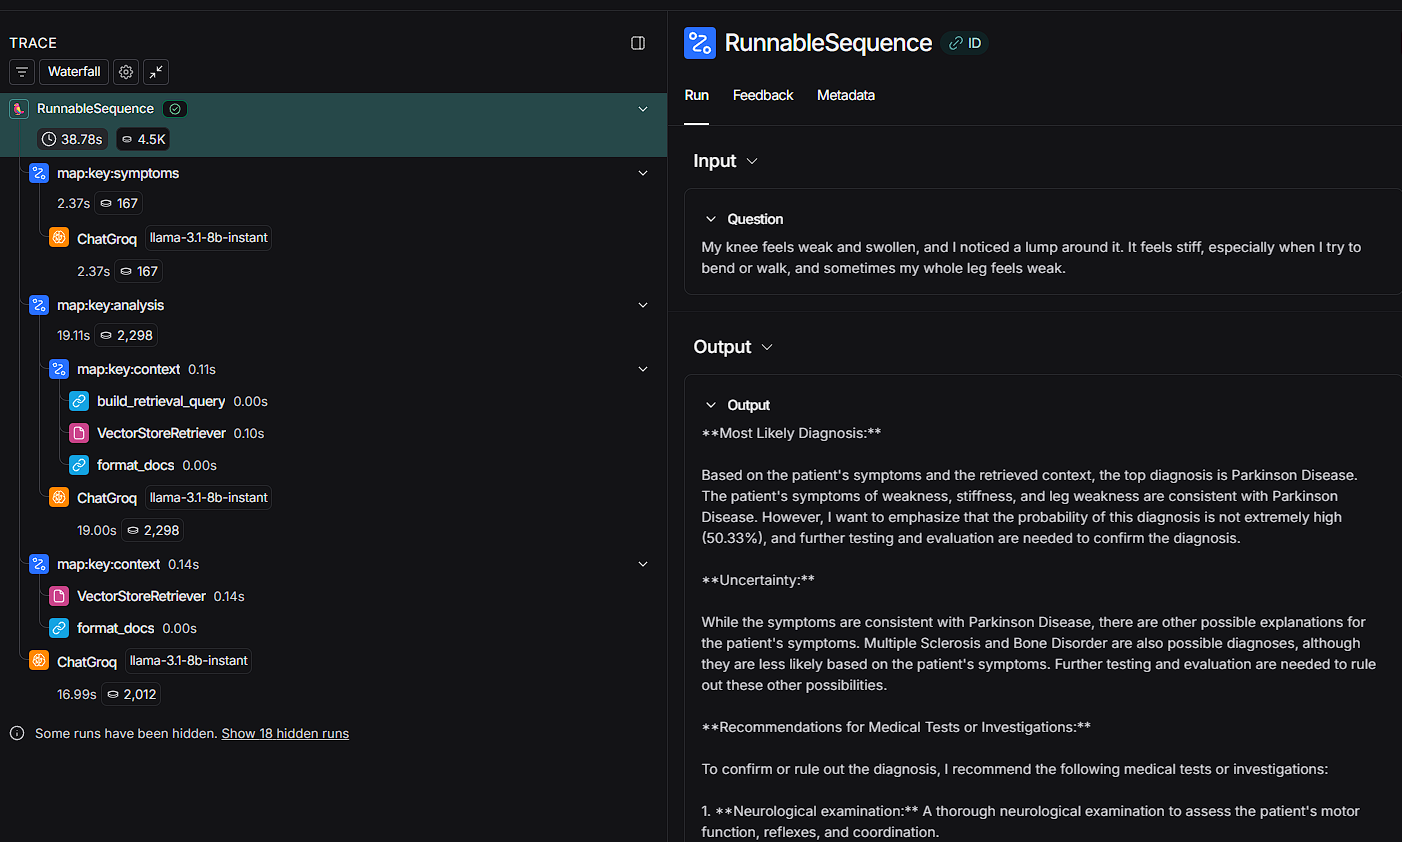